## Archival publication note

This copy preserves the submitted calculations and historical outputs. Local paths were made relative for publication. Read [README](README.md) and [AUDIT](../../AUDIT.md) before interpreting results. Edited original cell indices: [6, 26, 60, 80, 83, 86]. No fresh execution is claimed.


<font face="Times New Roman" size=5>
<div dir=rtl align="center">

<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>

<hr/>
<font color="#80a080" size=5>
Assignment 3: Regression  
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Spring 2026
<br>
</font>
<hr>
</div></font>

> - Full Name: **[Full Name]**
> - Student ID: **[Student ID]**

# Problem 1: Linear Regression

### Importing needed libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
%matplotlib inline

### Loading our housing dataset
We will load our data on house sales in King County to predict house prices using simple (one input) linear regression. We want to be able to predict Y which is our price variable.

In [16]:
dataset = pd.read_csv(r'kc_house_data.csv')
Y = dataset[['price']]
X = dataset.drop(['price', 'id', 'date'], axis=1)

### Data Analysis
We can perform basic data analysis using `info`, `describe`, and `head`.

using pandas `.info()` we see we have 18 columns and 21613 records. Pretty much all the features given are already in numeric format.

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       21613 non-null  int64  
 1   bathrooms      21613 non-null  float64
 2   sqft_living    21613 non-null  int64  
 3   sqft_lot       21613 non-null  int64  
 4   floors         21613 non-null  float64
 5   waterfront     21613 non-null  int64  
 6   view           21613 non-null  int64  
 7   condition      21613 non-null  int64  
 8   grade          21613 non-null  int64  
 9   sqft_above     21613 non-null  int64  
 10  sqft_basement  21613 non-null  int64  
 11  yr_built       21613 non-null  int64  
 12  yr_renovated   21613 non-null  int64  
 13  zipcode        21613 non-null  int64  
 14  lat            21613 non-null  float64
 15  long           21613 non-null  float64
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
dtypes: flo

In [18]:
columns = X.columns
columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [19]:
#show first 5 records
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


`.describe` generates descriptive statistics that summarize the central tendency, dispersion and shape of a dataset's distribution, excluding NaN values.

In [20]:
X.describe()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


We can alse compute correlation between variables and our predictor variable.

In [21]:
dataset = dataset.drop(['id', 'date'], axis=1)
dataset.corr(method='pearson')

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406
grade,0.667434,0.356967,0.664983,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,0.168392,0.446963,0.014414,-0.184862,0.114084,0.198372,0.713202,0.119248


for gaining better insight, we can visualize the table above.

In [22]:
plt.subplots(figsize=(5,4))
sns.heatmap(dataset.corr())

<Axes: >

Now that we have gained some insight about our dataset, we can implement linear regression.

## 1.1  Simple Linear Regression
We will start with **Simple Linear Regression** since it is easier to understand and visualize before moving to **Multiple Linear Regression**. Though, the concepts overall are similar and the libraries we will be using are actually designed to handle both without distinction. Simple Linear Regression is easier to plot and visualize so we will start with that.

It is **Simple Linear Regression** when we have one dependent variable (feature) and one independent variable. Here we will pick `sqft_living` as our independent variable `X`.

Our goal is to estimate $\hat{y} = x \theta_1 + \theta_0 $, where $ \theta_1 $ is our coefficient and $ \theta_0 $ is our intercept. To estimate $ \hat{y} $ we need to find a function such as $ \hat{y} = h(x) = x \theta_1 + \theta_0 $.

We first start by creating our `x` and `y` variables. Then plotting to gain an intuition on how the data looks like.


In [23]:
x = X[['sqft_living']]
y = Y

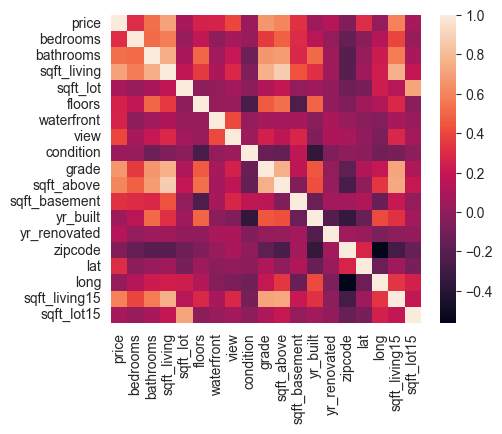

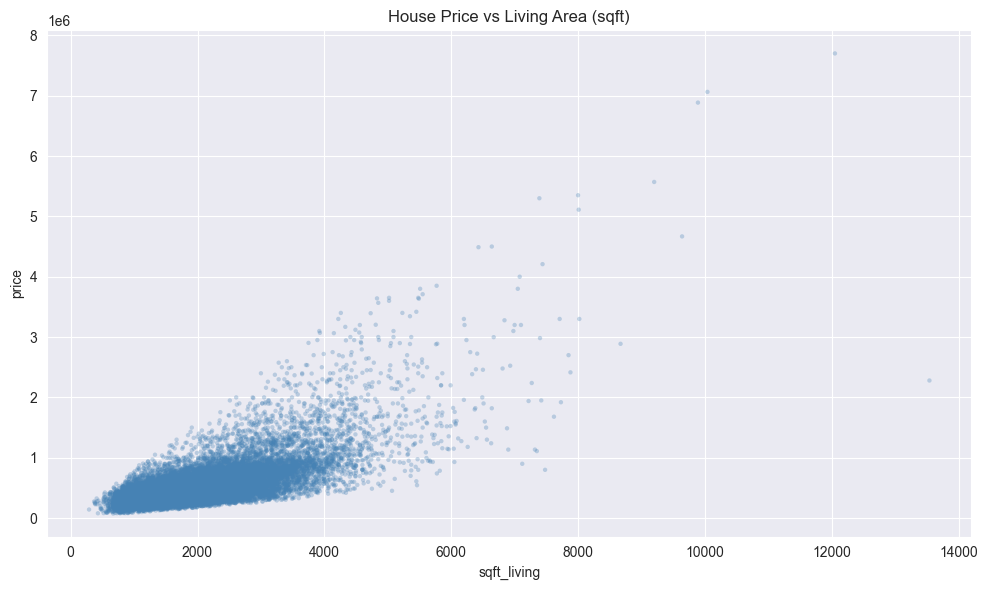

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.3, color='steelblue', edgecolors='none', s=10)
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.title('House Price vs Living Area (sqft)')
plt.tight_layout()
plt.show()

###  Gradient Descent Implementation

complete the TODO parts to implement linear regression.

In [25]:
# do not change this cell
x = X[['sqft_living']]
y = Y
xg = x.values.reshape(-1,1)
yg = y.values.reshape(-1,1)
xg = np.concatenate((np.ones(len(x)).reshape(-1,1), x), axis=1)

In [26]:
def computeCost(x, y, theta):
    m = len(y)
    predictions = x.dot(theta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost
    


In [28]:
def gradientDescent(x, y, theta, alpha, iterations):
    m = len(y)
    j_hist = []
    for _ in range(iterations):
        predictions = x.dot(theta)
        errors = predictions - y
        theta = theta - (alpha / m) * x.T.dot(errors)
        j_hist.append(computeCost(x, y, theta))
    return theta, j_hist

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xg_scaled = scaler.fit_transform(xg[:, 1].reshape(-1, 1))
xg_norm = np.concatenate((np.ones(len(xg_scaled)).reshape(-1, 1), xg_scaled), axis=1)#TODO: Normalize your data
from sklearn.preprocessing import StandardScaler


In [30]:
theta_init = np.zeros((2, 1))
alpha = 0.01
iterations = 1000

theta, cost = gradientDescent(xg_norm, yg, theta_init, alpha, iterations)
print('Theta found by Gradient Descent: slope = {} and intercept {}'.format(theta[1], theta[0]))

Theta found by Gradient Descent: slope = [257719.07230277] and intercept [540064.82548774]


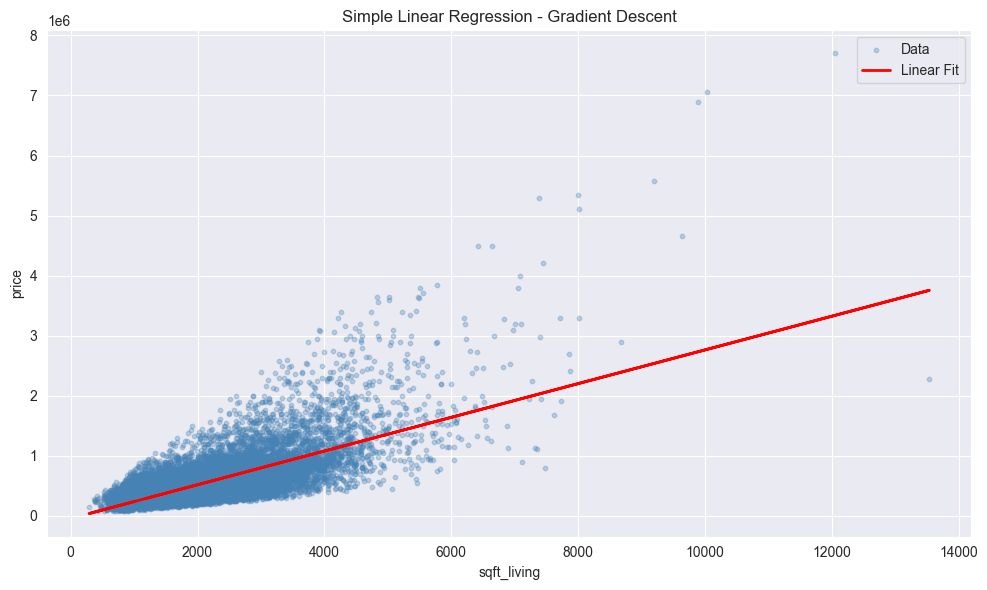

In [31]:
predictions = xg_norm.dot(theta)

plt.figure(figsize=(10, 6))
plt.scatter(xg[:, 1], yg, alpha=0.3, s=10, color='steelblue', label='Data')
plt.plot(xg[:, 1], predictions, color='red', linewidth=2, label='Linear Fit')
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.title('Simple Linear Regression - Gradient Descent')
plt.legend()
plt.tight_layout()
plt.show()

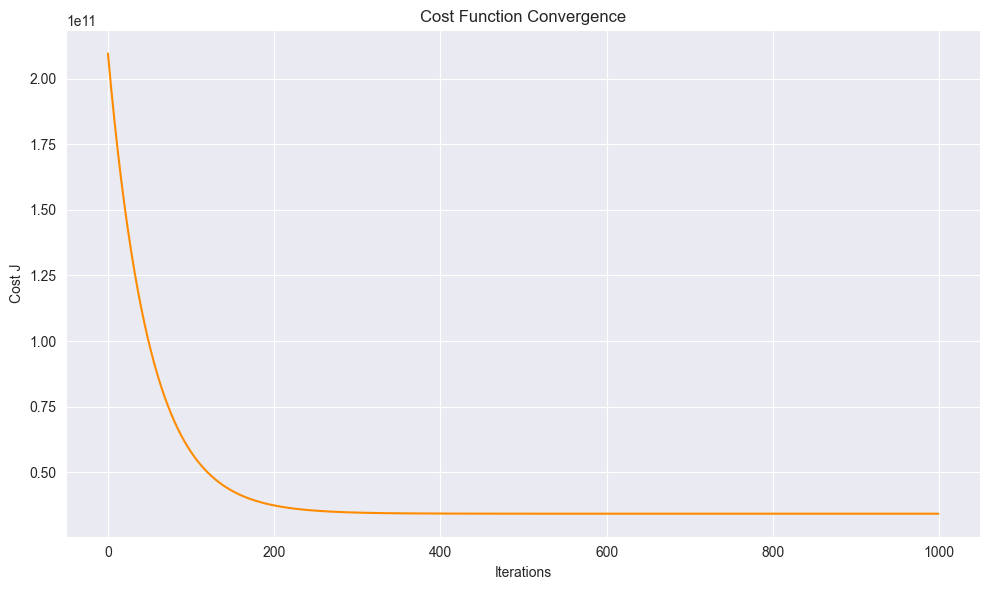

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), cost, color='darkorange')
plt.xlabel('Iterations')
plt.ylabel('Cost J')
plt.title('Cost Function Convergence')
plt.tight_layout()
plt.show()#TODO: visualize how the cost changes

## 1.2 Multiple Linear Regression
Multiple Linear Regression (MLR) is an extension of simple linear regression that models the relationship between two or more explanatory variables (features) and a dependent variable (target). 

Implement Multiple Linear Regression for this dataset.

Intercept: 6643873.527879483
Coefficients:
  bedrooms: -34335.4187
  bathrooms: 44564.5289
  sqft_living: 109.0158
  sqft_lot: 0.0888
  floors: 7003.1295
  waterfront: 562413.0700
  view: 53641.1070
  condition: 24526.7101
  grade: 94567.8917
  sqft_above: 70.0227
  sqft_basement: 38.9931
  yr_built: -2680.7689
  yr_renovated: 20.4156
  zipcode: -552.2530
  lat: 595968.1221
  long: -194585.7240
  sqft_living15: 21.2143
  sqft_lot15: -0.3258

MSE:  45173046132.79
RMSE: 212539.52
R²:   0.7012


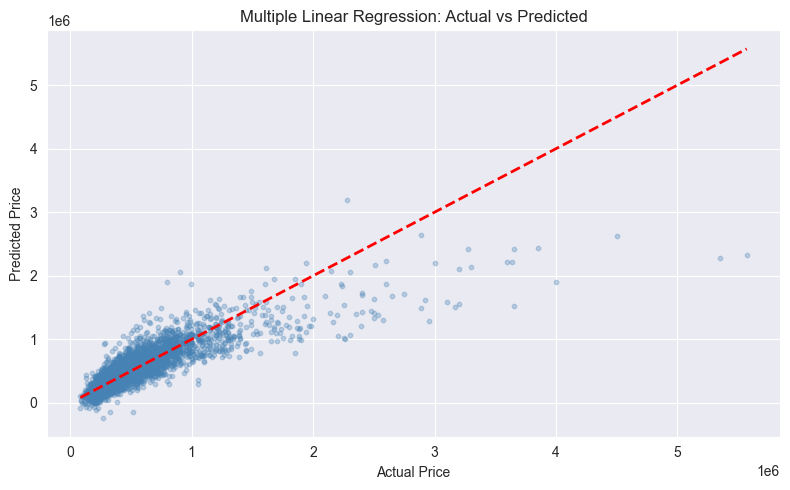

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred = mlr.predict(X_test)

print('Intercept:', mlr.intercept_[0])
print('Coefficients:')
for col, coef in zip(X.columns, mlr.coef_[0]):
    print(f'  {col}: {coef:.4f}')

print(f'\nMSE:  {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'R²:   {r2_score(y_test, y_pred):.4f}')

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min().values[0], y_test.max().values[0]],
         [y_test.min().values[0], y_test.max().values[0]], 'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

## 1.3 Linear Regression with Regularization

In traditional linear regression, we try to find the best-fitting line by minimizing the cost function . However, when dealing with complex data, overfitting can occur, especially when the model is too complex or when there are many features in the data.

To combat overfitting and improve the generalization of the model, regularization techniques are used. Regularization adds a penalty term to the cost function to constrain the model and prevent it from fitting the noise in the training data.

### Types of Regularization

#### 1. Ridge Regression (L2 Regularization):
Ridge regression adds a penalty term to the cost function that is proportional to the square of the coefficients. The goal is to shrink the coefficients toward zero but never exactly zero. This helps to reduce model complexity and prevent overfitting.

**Cost Function**:
$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 + \lambda \sum_{j=1}^{n} \theta_j^2
$

Where:
- $ \lambda $ is the regularization parameter (also called the **ridge penalty**).
- $ \theta_j $ are the model coefficients.
- The term $ \sum_{j=1}^{n} \theta_j^2 $ is the penalty term that controls the size of the coefficients. Larger $ \lambda $ values result in stronger regularization.

---

#### 2. Lasso Regression (L1 Regularization):
Lasso regression adds a penalty to the sum of the absolute values of the coefficients. The cost function is modified to include the sum of the absolute values of the coefficients. Lasso has the unique property that it can drive some of the coefficients exactly to zero, effectively performing feature selection.

**Cost Function**:
$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 + \lambda \sum_{j=1}^{n} |\theta_j|
$

Where:
- $ \lambda $ is the regularization parameter (also called the **lasso penalty**).
- The term $ \sum_{j=1}^{n} |\theta_j| $ is the penalty term that controls the magnitude of the coefficients. Lasso has the unique property that it can drive some coefficients exactly to zero.

In this question, we want to develope a class `linear regression` and add regularization to our model.


Explain **When to Use Ridge Regression and Lasso Regression**.


ANSWER:


Ridge Regression (L2) is best used when you have many features that all contribute
to the output and you want to keep all of them but shrink their coefficients to reduce
overfitting. It works well when multicollinearity exists between features.

Lasso Regression (L1) is best used when you suspect only a few features are truly
important and want automatic feature selection. Since Lasso can drive coefficients
exactly to zero, it effectively removes irrelevant features from the model, giving
a simpler and more interpretable result.

Also explain **the effect of the regularization parameter**: 


ANSWER :


The regularization parameter λ controls the strength of the penalty applied to the
model coefficients:

- When λ = 0: No regularization is applied, and the model behaves as standard
  linear regression, which may overfit the training data.

- When λ is small: The penalty is weak, the model is close to standard linear
  regression, and coefficients are only slightly shrunk.

- When λ is large: The penalty is strong, coefficients are heavily shrunk toward
  zero (Ridge) or set to exactly zero (Lasso), which can lead to underfitting if
  λ is too large.

The optimal λ is typically found using cross-validation.

Complete the code below for the linear regression class.

In [36]:
class LinearRegression:
    def __init__(self, lr=0.001, n_iters=1000, penalty=None, lambda_=0.1):
        self.lr = lr
        self.n_iters = n_iters
        self.penalty = penalty
        self.lambda_ = lambda_
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0

        for i in range(self.n_iters):
            y_pred = X.dot(self.weights) + self.bias
            errors = y_pred - y

            dw = (1 / m) * X.T.dot(errors)
            db = (1 / m) * np.sum(errors)

            if self.penalty == 'l1':
                dw += (self.lambda_ / m) * np.sign(self.weights) * np.abs(self.weights)
            elif self.penalty == 'l2':
                dw += (self.lambda_ / m) * 2 * self.weights

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return X.dot(self.weights) + self.bias

In [39]:
# Do not change this cell
n_samples = 1000
n_features = 10
X, y = make_regression(n_samples=n_samples, n_features=n_features, n_informative=5, noise=10, random_state=42)

Apply train-test split.

In [40]:
X_fit, X_val, y_fit, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


Visualize your data points.

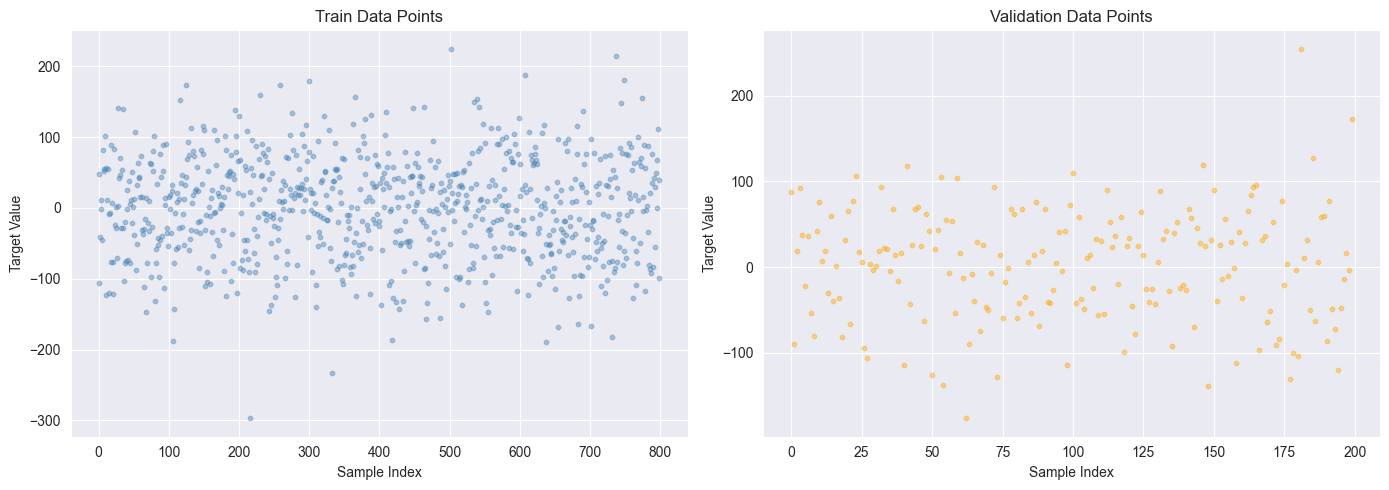

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(range(len(y_fit)), y_fit, alpha=0.4, s=10, color='steelblue')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Target Value')
ax1.set_title('Train Data Points')

ax2.scatter(range(len(y_val)), y_val, alpha=0.4, s=10, color='orange')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Target Value')
ax2.set_title('Validation Data Points')

plt.tight_layout()
plt.show()

Train your model and  evaluate your model using MMSE, $R^2$ criterions, how well is your model trained?

In [43]:
def mse(y, predictions):
    return np.mean((y - predictions) ** 2)


101.13803939898942


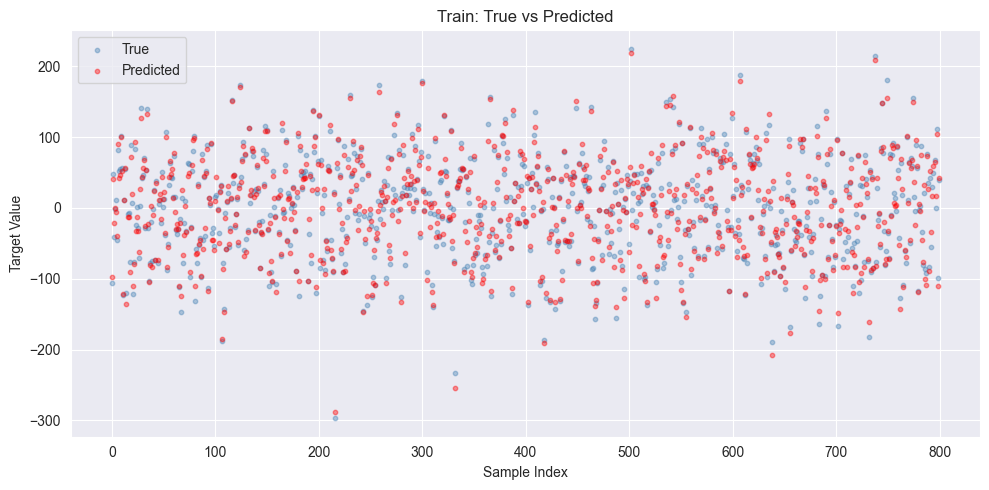

Train MSE: 101.1380
Train R²:  0.9800


In [44]:
model = LinearRegression(lr=0.01, n_iters=1000, penalty='l2', lambda_=0.1)
model.fit(X_fit, y_fit)
train_predictions = model.predict(X_fit)

y_pred_train = train_predictions

print(mse(y_fit, train_predictions))

plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_fit)), y_fit, alpha=0.4, s=10, color='steelblue', label='True')
plt.scatter(range(len(y_pred_train)), y_pred_train, alpha=0.4, s=10, color='red', label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title('Train: True vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

r2 = 1 - np.sum((y_fit - train_predictions)**2) / np.sum((y_fit - np.mean(y_fit))**2)
print(f'Train MSE: {mse(y_fit, train_predictions):.4f}')
print(f'Train R²:  {r2:.4f}')

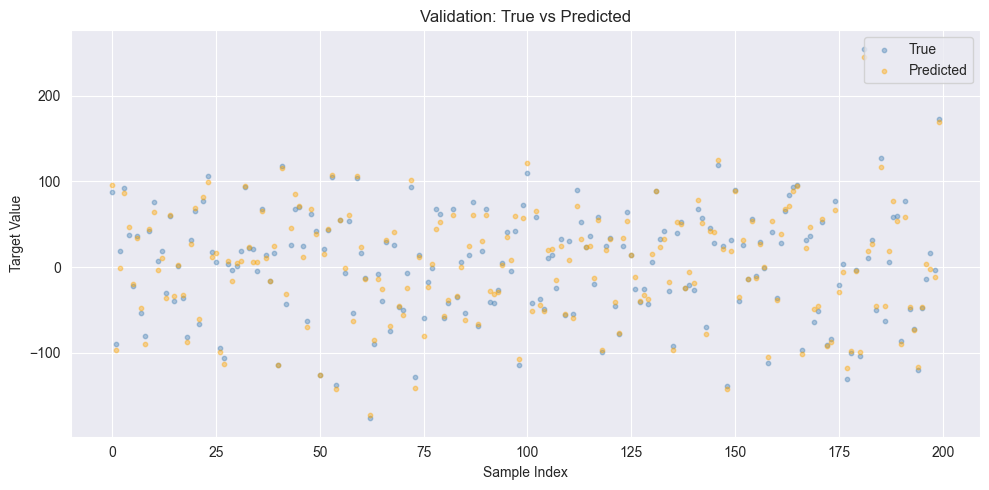

Validation MSE: 77.9137
Validation R²:  0.9815
77.91367703665051
77.91367703665051


In [45]:
y_pred_val = model.predict(X_val)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_val)), y_val, alpha=0.4, s=10, color='steelblue', label='True')
plt.scatter(range(len(y_pred_val)), y_pred_val, alpha=0.4, s=10, color='orange', label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title('Validation: True vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

r2_val = 1 - np.sum((y_val - y_pred_val)**2) / np.sum((y_val - np.mean(y_val))**2)
print(f'Validation MSE: {mse(y_val, y_pred_val):.4f}')
print(f'Validation R²:  {r2_val:.4f}')
print(mse(y_val, y_pred_val))

print(mse(y_val, y_pred_val))

### Ridge Regression:
Train your model using L2 regularization. Then change $\lambda$ and plot the train and test error with respect to $\lambda$. what is the best  $\lambda$?

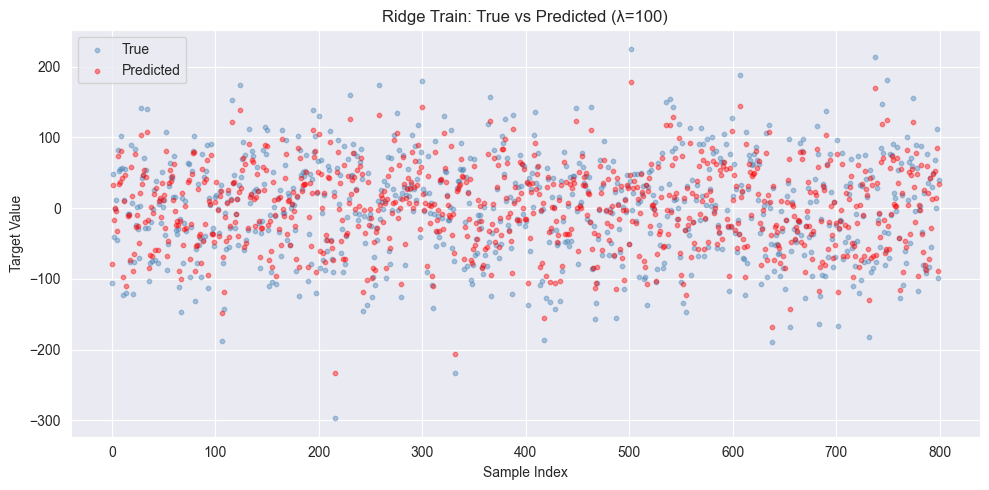

Train MSE: 285.3865
Train R²:  0.9434


In [46]:
lambdas = [0.001, 0.01, 0.1, 1, 10, 100]
train_errors = []
val_errors = []

for lam in lambdas:
    model_ridge = LinearRegression(lr=0.01, n_iters=1000, penalty='l2', lambda_=lam)
    model_ridge.fit(X_fit, y_fit)
    train_pred = model_ridge.predict(X_fit)
    train_errors.append(mse(y_fit, train_pred))

    r2_train = 1 - np.sum((y_fit - train_pred)**2) / np.sum((y_fit - np.mean(y_fit))**2)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_fit)), y_fit, alpha=0.4, s=10, color='steelblue', label='True')
plt.scatter(range(len(train_pred)), train_pred, alpha=0.4, s=10, color='red', label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title(f'Ridge Train: True vs Predicted (λ={lam})')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Train MSE: {train_errors[-1]:.4f}')
print(f'Train R²:  {r2_train:.4f}')



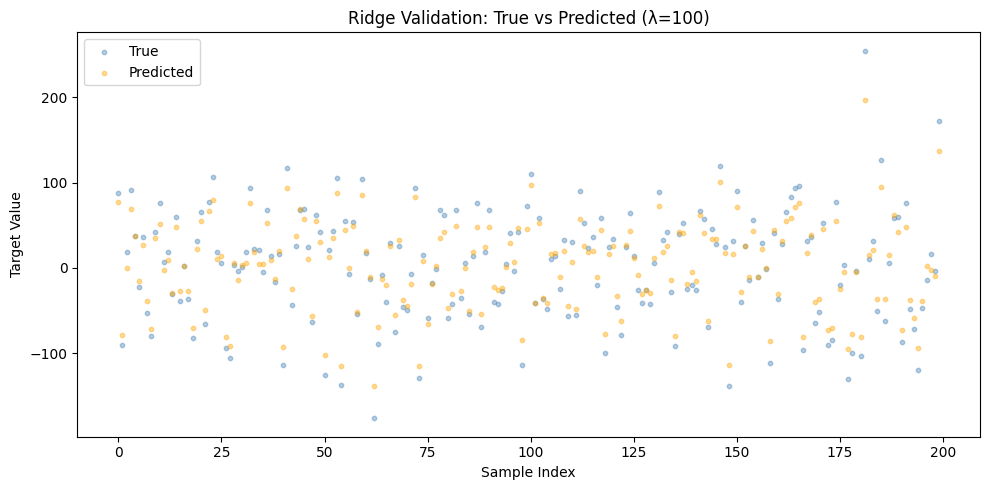

Validation MSE: 230.3129
Validation R²:  0.9453


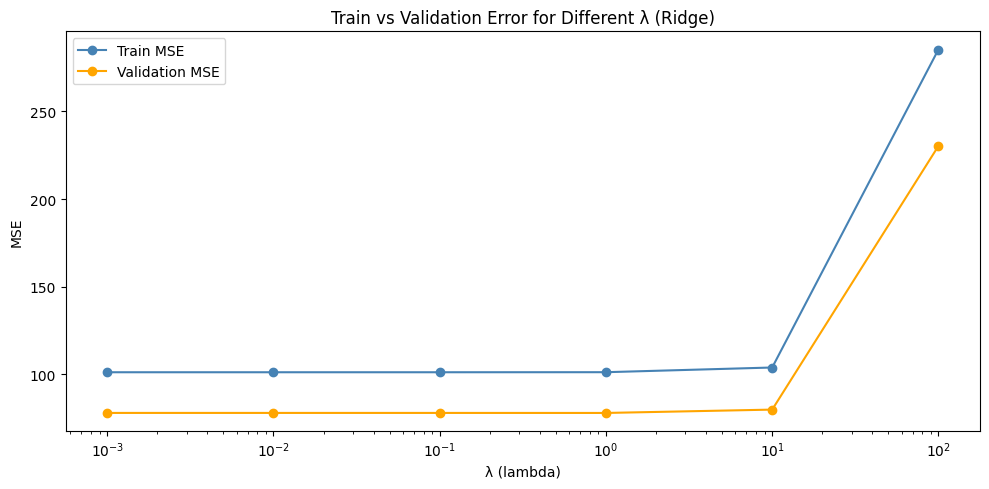

Best λ: 1


In [59]:
for lam in lambdas:
    model_ridge = LinearRegression(lr=0.01, n_iters=1000, penalty='l2', lambda_=lam)
    model_ridge.fit(X_fit, y_fit)
    val_pred = model_ridge.predict(X_val)
    val_errors.append(mse(y_val, val_pred))

    r2_val = 1 - np.sum((y_val - val_pred)**2) / np.sum((y_val - np.mean(y_val))**2)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_val)), y_val, alpha=0.4, s=10, color='steelblue', label='True')
plt.scatter(range(len(val_pred)), val_pred, alpha=0.4, s=10, color='orange', label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title(f'Ridge Validation: True vs Predicted (λ={lam})')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Validation MSE: {val_errors[-1]:.4f}')
print(f'Validation R²:  {r2_val:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(lambdas, train_errors, marker='o', color='steelblue', label='Train MSE')
plt.plot(lambdas, val_errors, marker='o', color='orange', label='Validation MSE')
plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('MSE')
plt.title('Train vs Validation Error for Different λ (Ridge)')
plt.legend()
plt.tight_layout()
plt.show()

best_lambda = lambdas[np.argmin(val_errors)]
print(f'Best λ: {best_lambda}')

### Lasso Regression:
This time train your model using L1 regularization. Then change $\lambda$ and plot the train and test error with respect to $\lambda$. what is the best  $\lambda$?

repeat the things you did in the previous part for Lasso Regression.

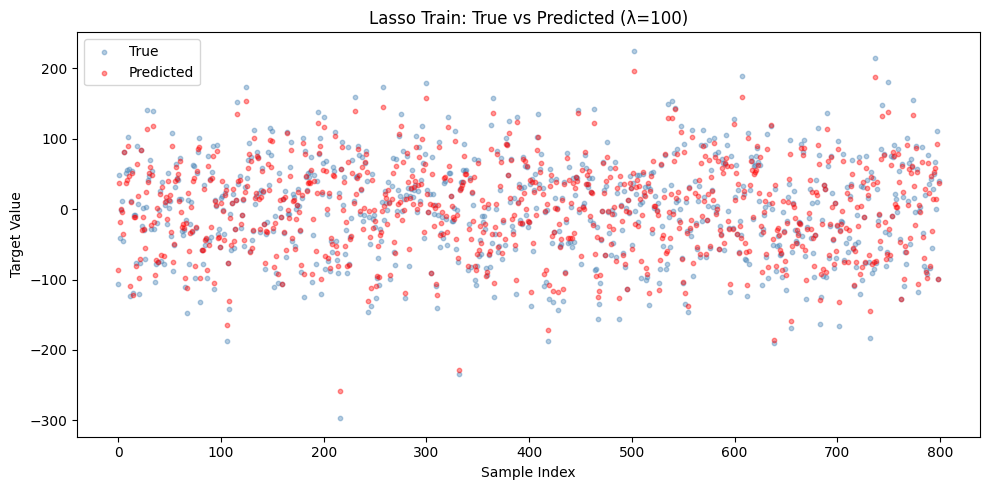

Train MSE: 157.6083
Train R²:  0.9688


In [60]:
lambdas = [0.001, 0.01, 0.1, 1, 10, 100]
train_errors_lasso = []
val_errors_lasso = []

for lam in lambdas:
    model_lasso = LinearRegression(lr=0.01, n_iters=1000, penalty='l1', lambda_=lam)
    model_lasso.fit(X_fit, y_fit)
    train_pred = model_lasso.predict(X_fit)
    train_errors_lasso.append(mse(y_fit, train_pred))

r2_train = 1 - np.sum((y_fit - train_pred)**2) / np.sum((y_fit - np.mean(y_fit))**2)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_fit)), y_fit, alpha=0.4, s=10, color='steelblue', label='True')
plt.scatter(range(len(train_pred)), train_pred, alpha=0.4, s=10, color='red', label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title(f'Lasso Train: True vs Predicted (λ={lam})')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Train MSE: {train_errors_lasso[-1]:.4f}')
print(f'Train R²:  {r2_train:.4f}')

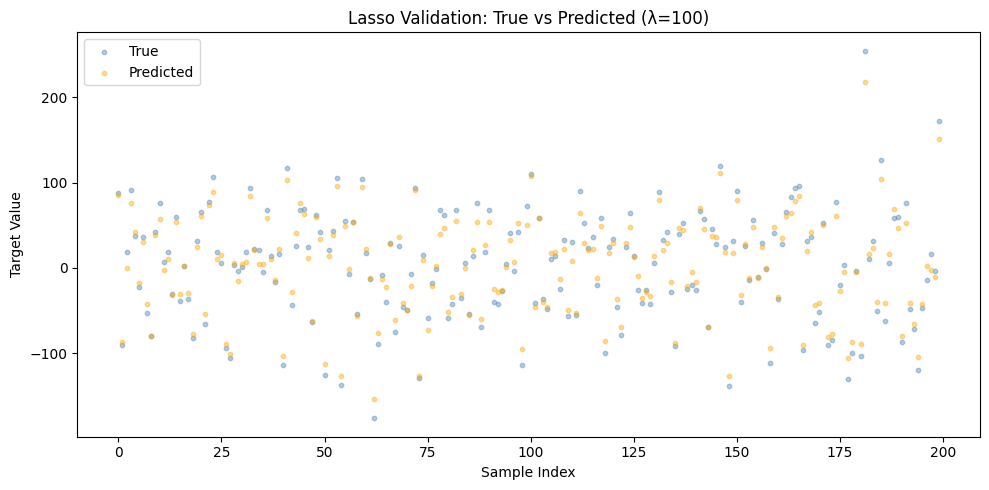

Validation MSE: 123.8484
Validation R²:  0.9706


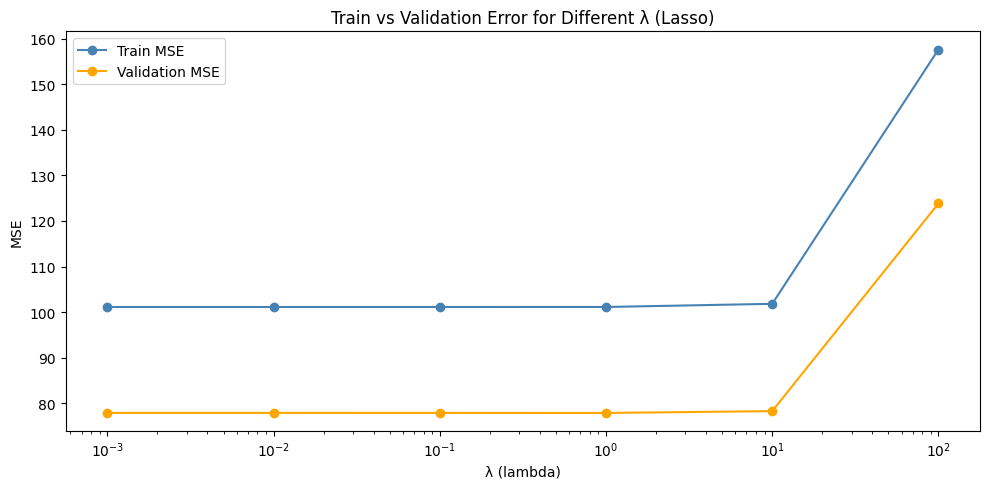

Best λ: 1


In [61]:
for lam in lambdas:
    model_lasso = LinearRegression(lr=0.01, n_iters=1000, penalty='l1', lambda_=lam)
    model_lasso.fit(X_fit, y_fit)
    val_pred = model_lasso.predict(X_val)
    val_errors_lasso.append(mse(y_val, val_pred))

r2_val = 1 - np.sum((y_val - val_pred)**2) / np.sum((y_val - np.mean(y_val))**2)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_val)), y_val, alpha=0.4, s=10, color='steelblue', label='True')
plt.scatter(range(len(val_pred)), val_pred, alpha=0.4, s=10, color='orange', label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title(f'Lasso Validation: True vs Predicted (λ={lam})')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Validation MSE: {val_errors_lasso[-1]:.4f}')
print(f'Validation R²:  {r2_val:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(lambdas, train_errors_lasso, marker='o', color='steelblue', label='Train MSE')
plt.plot(lambdas, val_errors_lasso, marker='o', color='orange', label='Validation MSE')
plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('MSE')
plt.title('Train vs Validation Error for Different λ (Lasso)')
plt.legend()
plt.tight_layout()
plt.show()

best_lambda_lasso = lambdas[np.argmin(val_errors_lasso)]
print(f'Best λ: {best_lambda_lasso}')

# Problem 2 : Discriminant Analysis and Generative Modeling

## Introduction
In this assignment, you will implement Linear Discriminant Analysis (LDA) and Quadratic Discriminant Analysis (QDA) from scratch. We will explore the generative nature of these models and analyze their robustness to noise. By the end of this assignment, you will be able to quantify the performance degradation caused by noisy data and understand the theoretical differences between these classical approaches.

### Import Libraries

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Loading and Visualization 
Load the provided discriminant_data.csv. Visualize the distribution to identify the three classes.

          x         y  label
0  1.638965  1.500701      0
1  0.677570  2.200600      0
2  2.319851  2.085714      0
3  0.248644  1.016079      0
4  2.135297  2.677857      0
(300, 3)
label
0    100
1    100
2    100
Name: count, dtype: int64


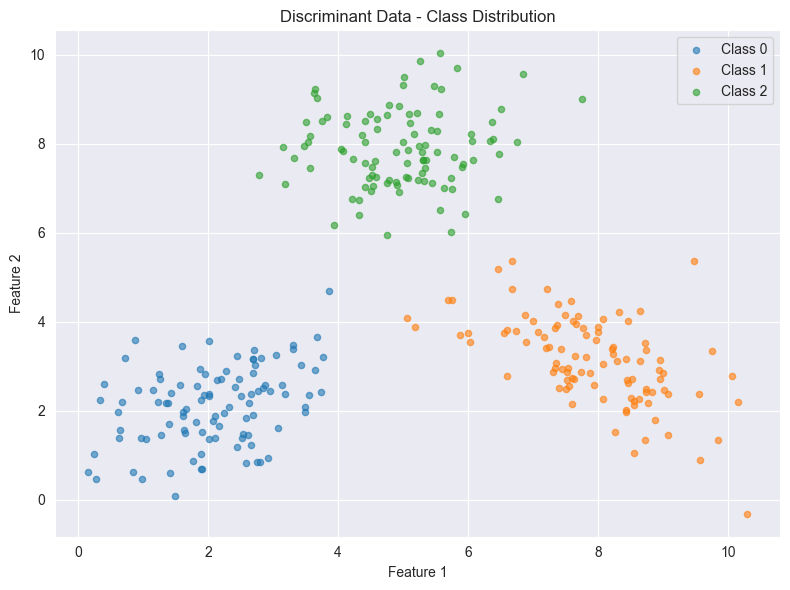

In [55]:
dataset = pd.read_csv(r'discriminant_data.csv')

print(dataset.head())
print(dataset.shape)
print(dataset['label'].value_counts())

fig, ax = plt.subplots(figsize=(8, 6))
for label, group in dataset.groupby('label'):
    ax.scatter(group.iloc[:, 0], group.iloc[:, 1], label=f'Class {label}', alpha=0.6, s=20)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Discriminant Data - Class Distribution')
ax.legend()
plt.tight_layout()
plt.show()

## Discriminant Analysis Implementation
Implement the fit and predict functions for both LDA and QDA.

### LDA

LDA Accuracy: 1.0000


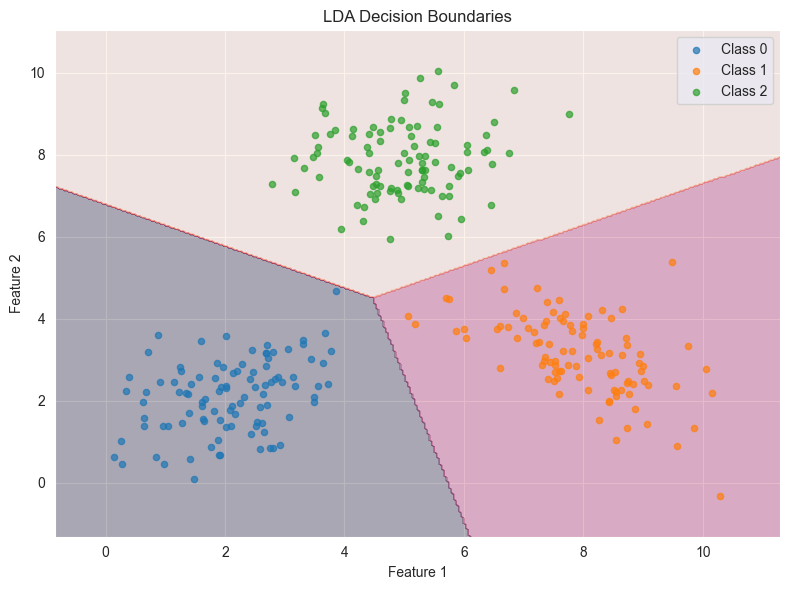

In [56]:
def fit_lda(X, y):
    classes = np.unique(y)
    means = {}
    priors = {}
    n, d = X.shape
    cov_pooled = np.zeros((d, d))

    for c in classes:
        X_c = X[y == c]
        means[c] = np.mean(X_c, axis=0)
        priors[c] = len(X_c) / n
        cov_pooled += (len(X_c) - 1) * np.cov(X_c.T)

    cov_pooled /= (n - len(classes))
    return means, cov_pooled, priors


def predict_lda(X_test, means, cov, priors):
    scores = []
    cov_inv = np.linalg.inv(cov)

    for c in means:
        mu = means[c]
        prior = priors[c]
        score = X_test.dot(cov_inv).dot(mu) - 0.5 * mu.dot(cov_inv).dot(mu) + np.log(prior)
        scores.append(score)

    return np.argmax(np.array(scores), axis=0)


# Visualization code for decision boundaries
X = dataset.drop('label', axis=1).values
y = dataset['label'].values

means, cov_pooled, priors = fit_lda(X, y)
y_pred = predict_lda(X, means, cov_pooled, priors)

accuracy = np.mean(y_pred == y)
print(f'LDA Accuracy: {accuracy:.4f}')

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict_lda(grid, means, cov_pooled, priors).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f'Class {label}', s=20, alpha=0.7)
plt.title('LDA Decision Boundaries')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

### QDA

QDA Accuracy: 1.0000


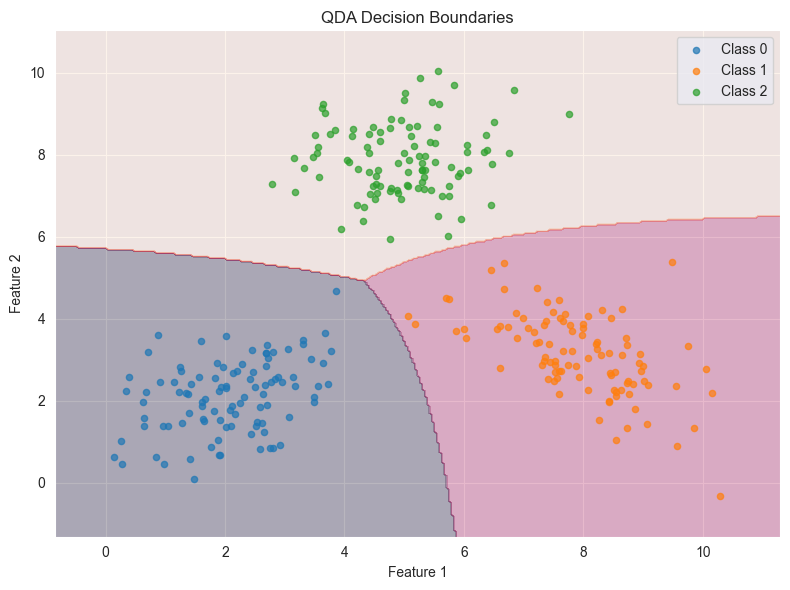

In [57]:
def fit_qda(X, y):
    classes = np.unique(y)
    means = {}
    covs = {}
    priors = {}
    n = len(y)

    for c in classes:
        X_c = X[y == c]
        means[c] = np.mean(X_c, axis=0)
        covs[c] = np.cov(X_c.T)
        priors[c] = len(X_c) / n

    return means, covs, priors


def predict_qda(X_test, means, covs, priors):
    scores = []

    for c in means:
        mu = means[c]
        cov = covs[c]
        cov_inv = np.linalg.inv(cov)
        sign, log_det = np.linalg.slogdet(cov)
        diff = X_test - mu
        score = -0.5 * np.sum(diff.dot(cov_inv) * diff, axis=1) - 0.5 * log_det + np.log(priors[c])
        scores.append(score)

    return np.argmax(np.array(scores), axis=0)


# Visualization
means_q, covs_q, priors_q = fit_qda(X, y)
y_pred_qda = predict_qda(X, means_q, covs_q, priors_q)

accuracy_qda = np.mean(y_pred_qda == y)
print(f'QDA Accuracy: {accuracy_qda:.4f}')

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict_qda(grid, means_q, covs_q, priors_q).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f'Class {label}', s=20, alpha=0.7)
plt.title('QDA Decision Boundaries')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

## Robustness to Noise
A robust model should handle outliers effectively. We will test how your models handle sensor noise (random outliers).
Implement the function below to inject noise into the dataset. Use np.random.seed(42) to ensure consistency for grading.

In [58]:
def add_noise(X, y, seed=42):
    np.random.seed(seed)
    n_outliers = 50
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    outliers_X = np.column_stack([
        np.random.uniform(x_min, x_max, n_outliers),
        np.random.uniform(y_min, y_max, n_outliers)
    ])
    outliers_y = np.random.randint(0, 3, n_outliers)

    X_noisy = np.vstack([X, outliers_X])
    y_noisy = np.concatenate([y, outliers_y])

    return X_noisy, y_noisy

Re-train your LDA and QDA models on the noisy dataset and visualize the new boundaries. Observe how the decision regions warp in response to the outliers.

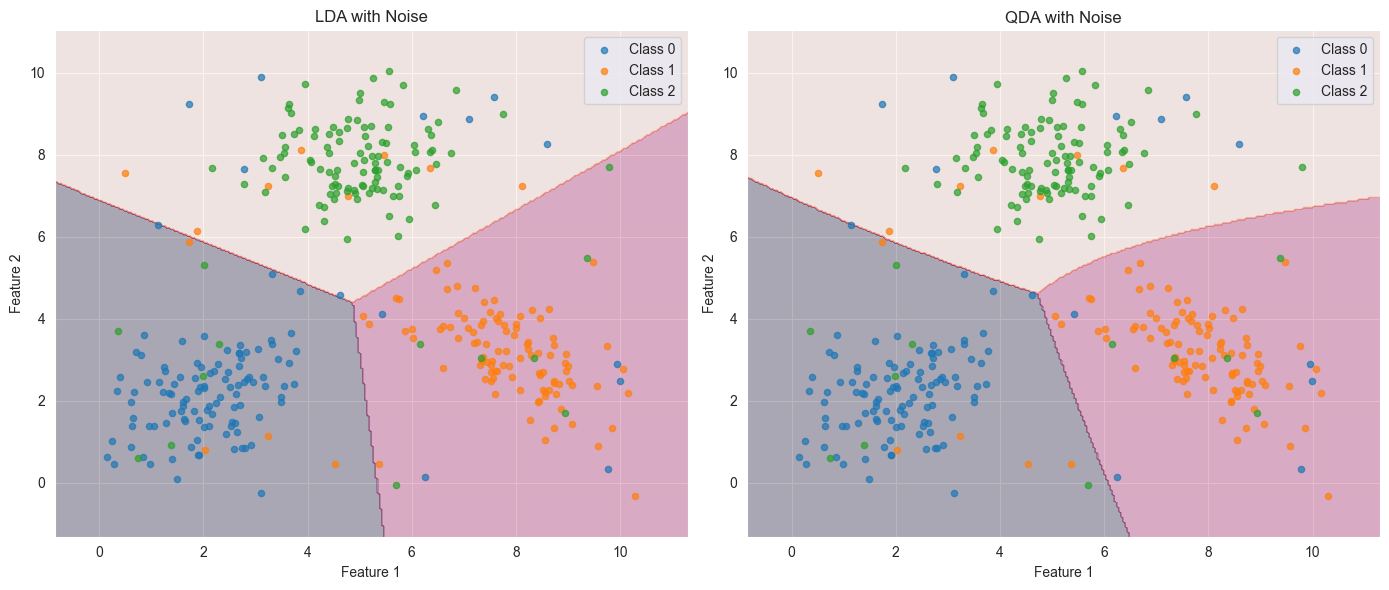

LDA Accuracy with Noise: 0.8914
QDA Accuracy with Noise: 0.8943


In [59]:
X_noisy, y_noisy = add_noise(X, y)

means_lda_n, cov_lda_n, priors_lda_n = fit_lda(X_noisy, y_noisy)
means_qda_n, covs_qda_n, priors_qda_n = fit_qda(X_noisy, y_noisy)

x_min, x_max = X_noisy[:, 0].min() - 1, X_noisy[:, 0].max() + 1
y_min, y_max = X_noisy[:, 1].min() - 1, X_noisy[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_lda = predict_lda(grid, means_lda_n, cov_lda_n, priors_lda_n).reshape(xx.shape)
Z_qda = predict_qda(grid, means_qda_n, covs_qda_n, priors_qda_n).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].contourf(xx, yy, Z_lda, alpha=0.3)
for label in np.unique(y_noisy):
    axes[0].scatter(X_noisy[y_noisy == label, 0], X_noisy[y_noisy == label, 1],
                    label=f'Class {label}', s=20, alpha=0.7)
axes[0].set_title('LDA with Noise')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()

axes[1].contourf(xx, yy, Z_qda, alpha=0.3)
for label in np.unique(y_noisy):
    axes[1].scatter(X_noisy[y_noisy == label, 0], X_noisy[y_noisy == label, 1],
                    label=f'Class {label}', s=20, alpha=0.7)
axes[1].set_title('QDA with Noise')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

y_pred_lda_n = predict_lda(X_noisy, means_lda_n, cov_lda_n, priors_lda_n)
y_pred_qda_n = predict_qda(X_noisy, means_qda_n, covs_qda_n, priors_qda_n)
print(f'LDA Accuracy with Noise: {np.mean(y_pred_lda_n == y_noisy):.4f}')
print(f'QDA Accuracy with Noise: {np.mean(y_pred_qda_n == y_noisy):.4f}')

## Generative Modeling
Since these models are generative, we can treat them as a probability distribution. Use your fitted parameters ($\mu_k$ and $\Sigma_k$) to generate synthetic data points.

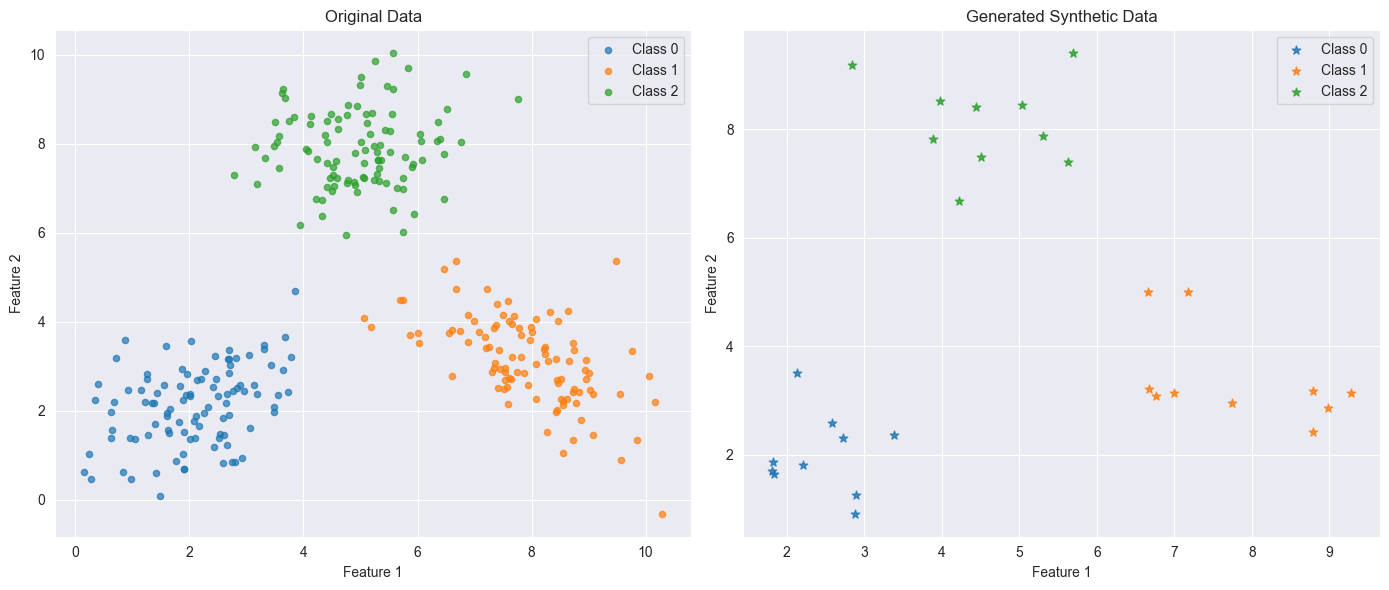

In [60]:
def generate_data(means, covs, n_samples_per_class=10):
    generated_data = []
    for c in means:
        samples = np.random.multivariate_normal(means[c], covs[c], n_samples_per_class)
        generated_data.append(samples)
    return np.vstack(generated_data)

# Plotting original vs generated
generated = generate_data(means_q, covs_q, n_samples_per_class=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label in np.unique(y):
    axes[0].scatter(X[y == label, 0], X[y == label, 1], label=f'Class {label}', s=20, alpha=0.7)
axes[0].set_title('Original Data')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()

n = len(generated) // len(means_q)
for i, c in enumerate(means_q):
    chunk = generated[i*n:(i+1)*n]
    axes[1].scatter(chunk[:, 0], chunk[:, 1], label=f'Class {c}', s=40, alpha=0.8, marker='*')
axes[1].set_title('Generated Synthetic Data')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

## Quantitative Evaluation of Generative Models
Unlike discriminative models where we rely on metrics like accuracy or precision to judge decision boundaries, generative models are evaluated based on their ability to capture the underlying probability distribution of the data. While visual inspection allows us to check for "plausibility," we require mathematical metrics to rigorously quantify "fidelity."

We will use two key methods to evaluate how well our model's generated distribution $Q$ matches the true distribution of the original data $P$:

### 6.1. Information Theoretic Metric: KL Divergence

The Kullback-Leibler (KL) Divergence measures the information lost when we approximate the true distribution $P$ with our model's distribution $Q$. It is defined as:


$$D_{KL}(P || Q) = \sum_{x \in \mathcal{X}} P(x) \ln \left( \frac{P(x)}{Q(x)} \right)$$


In our implementation, since the data is continuous, we approximate this by discretizing the feature space into a 2D grid (bins) and computing the relative frequencies.

### 6.2. Statistical Moment Matching

Since our discriminant analysis models assume Gaussian distributions, we can evaluate the model by comparing the first two moments (Mean and Covariance) of the original data ($P$) vs. the generated samples ($Q$):

* **Mean Error:** $\|\mu_{original} - \mu_{generated}\|$
* **Covariance Error:** $\|\Sigma_{original} - \Sigma_{generated}\|$


In [61]:
def calculate_kl_divergence(original, generated, bins=20):
    p_hist, x_edges, y_edges = np.histogram2d(original[:, 0], original[:, 1], bins=bins, density=True)
    q_hist, _, _ = np.histogram2d(generated[:, 0], generated[:, 1], bins=[x_edges, y_edges], density=True)

    p = p_hist.ravel() + 1e-10
    q = q_hist.ravel() + 1e-10
    p = p / p.sum()
    q = q / q.sum()

    kl = np.sum(p * np.log(p / q))
    return kl


def compare_statistics(original, generated):
    mu_orig = np.mean(original, axis=0)
    mu_gen = np.mean(generated, axis=0)
    mu_diff = np.linalg.norm(mu_orig - mu_gen)

    cov_orig = np.cov(original.T)
    cov_gen = np.cov(generated.T)
    cov_diff = np.linalg.norm(cov_orig - cov_gen)

    return mu_diff, cov_diff

Generate samples using the parameters obtained from your model trained on the original dataset. Use the functions above to report the KL Divergence and statistical errors.

Repeat the process using the parameters obtained from your model trained on the noisy dataset (from Section 4).

Compare your metrics for the "Clean" vs. "Noisy" experiments.

In [62]:
gen_clean = generate_data(means_q, covs_q, n_samples_per_class=100)
gen_noisy = generate_data(means_qda_n, covs_qda_n, n_samples_per_class=100)

kl_clean = calculate_kl_divergence(X, gen_clean)
kl_noisy = calculate_kl_divergence(X_noisy, gen_noisy)

mu_diff_clean, cov_diff_clean = compare_statistics(X, gen_clean)
mu_diff_noisy, cov_diff_noisy = compare_statistics(X_noisy, gen_noisy)

print(' Clean Dataset ')
print(f'KL Divergence:      {kl_clean:.4f}')
print(f'Mean Error:         {mu_diff_clean:.4f}')
print(f'Covariance Error:   {cov_diff_clean:.4f}')

print('\n Noisy Dataset ')
print(f'KL Divergence:      {kl_noisy:.4f}')
print(f'Mean Error:         {mu_diff_noisy:.4f}')
print(f'Covariance Error:   {cov_diff_noisy:.4f}')

 Clean Dataset 
KL Divergence:      4.4959
Mean Error:         0.0362
Covariance Error:   0.5788

 Noisy Dataset 
KL Divergence:      8.1467
Mean Error:         0.1125
Covariance Error:   0.5865


Does the inclusion of noise increase the KL Divergence? Based on the Mean and Covariance error metrics, which parameter ($\mu$ or $\Sigma$) is more heavily distorted by the presence of outliers? Explain why this happens given the mathematical definition of Mean and Covariance.
---
ANSWER :
yes , noise increases the KL Divergence from 4.50 to 8.15, confirming the generated
distribution matches the true data less faithfully when trained on noisy data.

Based on the results:
- Mean Error:       0.0362 → 0.1125  (3x increase)
- Covariance Error: 0.5788 → 0.5865  (barely changed)

The Mean (μ) is more heavily distorted by outliers in this case.

This makes sense mathematically:
- μ = (1/n) Σ xᵢ  — outliers directly shift the mean since every point contributes
  equally, and 50 random outliers spread across wrong class regions pull μ away
  from the true class center.

- Σ = (1/n) Σ (xᵢ - μ)(xᵢ - μ)ᵀ — covariance measures spread around the mean.
  Since our outliers were injected uniformly within the data bounds (not extreme
  values), they add variance roughly symmetrically, causing only a small change
  in Σ relative to the original.

In short: μ is sensitive to where points land, while Σ is sensitive to how
spread out they are — and our uniformly distributed outliers shift locations
more than they change spread.

## Theorical Questions

### Q1. LDA vs. QDA:
Explain the mathematical assumption that makes LDA boundaries linear and QDA boundaries quadratic. Under what specific conditions would you expect LDA to outperform QDA, and vice-versa?

ANSWER :

LDA assumes all classes share the same covariance matrix Σ. This shared covariance causes the quadratic terms to cancel when computing the log-posterior ratio between classes, leaving only linear terms in x — hence linear boundaries. QDA allows each class k to have its own covariance matrix Σₖ, so the quadratic terms do not cancel, producing quadratic decision boundaries.

**LDA outperforms QDA when:**
- The equal-covariance assumption holds (or approximately holds)
- Training data is limited — LDA estimates fewer parameters (one shared Σ vs k separate Σₖ), making it less prone to overfitting

**QDA outperforms LDA when:**
- Classes have clearly different covariance structures
- Sufficient data is available to reliably estimate per-class covariance matrices



### Q2. Robustness and Noise:
Based on your plots from Section 4, which model (LDA or QDA) was more affected by the injected noise? Provide a mathematical intuition for your observation based on how these models calculate their covariance matrices.


ANSWER:


QDA is more affected by injected noise. Since QDA estimates a separate covariance matrix Σₖ per class, outliers assigned to a class directly distort that class's Σₖ. LDA pools all class covariances into one shared estimate, effectively averaging out the effect of outliers across all classes, making it more robust. Mathematically, the pooled covariance in LDA is: Σ_pooled = Σₖ (nₖ-1)Σₖ / (n - K), which dilutes the impact of any single class's outliers.


### Q3. Generative Modeling:
Explain the "generative" intuition behind Discriminant Analysis. Why is it called a "Generative Model" instead of a "Discriminative Model"?
ANSWER:

Discriminant Analysis is called a generative model because it learns the joint distribution P(X, y) = P(X|y)P(y) — that is, it models how the data X is generated for each class y. It fits a class-conditional Gaussian P(X|y=k) = N(μₖ, Σₖ) and a prior P(y=k). Classification is then done via Bayes' theorem: P(y=k|X) ∝ P(X|y=k)P(y=k). Because we have an explicit model of how data is generated per class, we can sample new synthetic points from P(X|y=k), which is exactly what we did in Section 5. A discriminative model like logistic regression, by contrast, learns P(y|X) directly and cannot generate new data.

### Q4. Metrics:
KL Divergence: We used KL Divergence to measure the discrepancy between the original data distribution $P$ and our generated distribution $Q$. Mathematically, explain why $D_{KL}(P || Q)$ is not a true "distance" (i.e., why it is not symmetric). What does a high KL Divergence tell us about the quality of our generative parameters?

 Why is comparing the first moment (Mean) and the second moment (Covariance) a sufficient way to evaluate our model's performance? Hint: Relate your answer to the functional form of the Multivariate Normal Distribution:$$f(x) = \frac{1}{\sqrt{(2\pi)^k |\Sigma|}} \exp\left(-\frac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)\right)$$

ANSWER :
**Non-symmetry:** DKL(P||Q) = Σ P(x) ln(P(x)/Q(x)), which is not equal to DKL(Q||P) = Σ Q(x) ln(Q(x)/P(x)) in general. The asymmetry arises because P and Q play different roles — P weights the log ratio, so regions where P is large but Q is small are heavily penalized, while regions where Q is large but P is small are ignored. Swapping P and Q changes which regions are penalized, giving a different value. Therefore it cannot be a true distance metric.

**High KL Divergence** means the generated distribution Q places probability mass in regions very different from P, indicating poor generative quality — the model's learned parameters fail to capture the true data distribution.

**Why Mean and Covariance are sufficient:** The Multivariate Normal is fully characterized by exactly two parameters — μ and Σ. Since f(x) = 1/√((2π)ᵏ|Σ|) · exp(-½(x-μ)ᵀΣ⁻¹(x-μ)), once μ and Σ are matched, the entire distribution is matched. There are no higher-order moments to worry about. Therefore, comparing the first moment (mean) and second moment (covariance) is not just sufficient but complete for evaluating how well our Gaussian generative model has captured the true distribution.

# Problem 3: Some Minor Questions...

### Problem 3.1: Heteroskedastic Regression

Standard linear regression assumes constant variance. Given a dataset $\{x, y\}$ where the spread changes with the input (heteroskedasticity):  
- Explore: Plot the data to identify the non-linear mean trend and the input-dependent variance.
- Model: Propose functional forms for $\mu(x)$ and $\sigma^2(x)$ to formulate the full conditionally Gaussian model $p(y|x)$.  
- Estimate: Use Weighted Least Squares (WLS) to calculate the optimal parameters for your mean function.

Find the datapoints in the `heteroskedastic_data.csv`

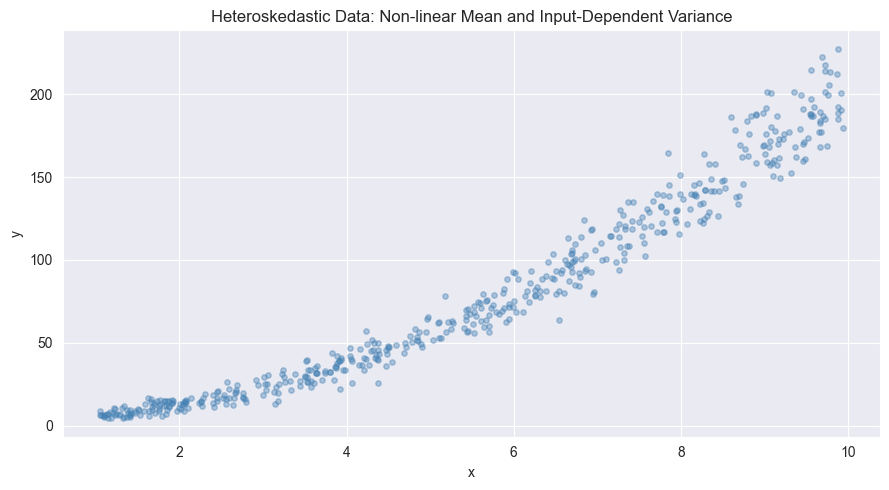

WLS Parameters: θ₀=3.6637, θ₁=0.6170, θ₂=1.9542


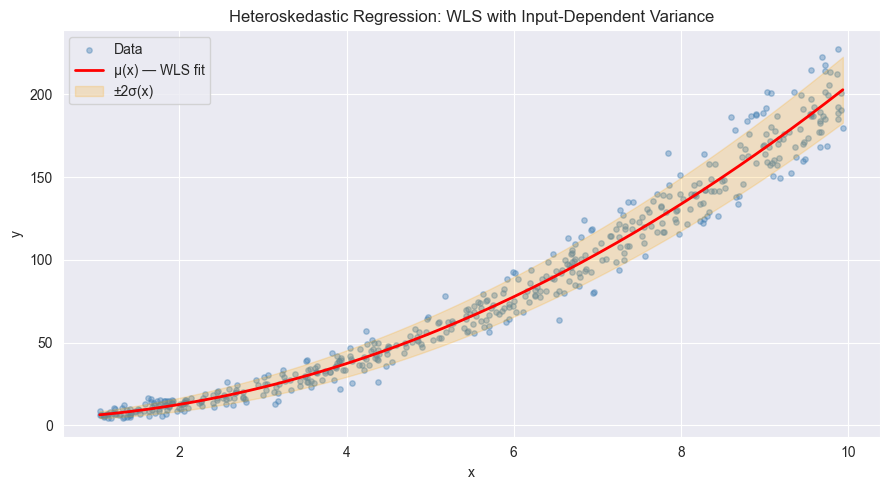

In [5]:
# Problem 3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load data
data = pd.read_csv(r'heteroskedastic_data.csv')
x = data.iloc[:, 0].values
y = data.iloc[:, 1].values

# first we plot the data
plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.4, s=15, color='steelblue')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Heteroskedastic Data: Non-linear Mean and Input-Dependent Variance')
plt.tight_layout()
plt.show()


Phi = np.column_stack([np.ones_like(x), x, x**2])

#  weights:
weights = 1.0 / (np.abs(x) + 1e-6)**2
W = np.diag(weights)

# WLS closed form
theta = np.linalg.inv(Phi.T @ W @ Phi) @ Phi.T @ W @ y
print(f'WLS Parameters: θ₀={theta[0]:.4f}, θ₁={theta[1]:.4f}, θ₂={theta[2]:.4f}')

# plot
x_sorted = np.linspace(x.min(), x.max(), 300)
Phi_sorted = np.column_stack([np.ones_like(x_sorted), x_sorted, x_sorted**2])
mu_pred = Phi_sorted @ theta
sigma_pred = np.abs(x_sorted) + 1e-6

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.4, s=15, color='steelblue', label='Data')
plt.plot(x_sorted, mu_pred, color='red', linewidth=2, label='μ(x) — WLS fit')
plt.fill_between(x_sorted, mu_pred - 2*sigma_pred, mu_pred + 2*sigma_pred,
                 alpha=0.2, color='orange', label='±2σ(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Heteroskedastic Regression: WLS with Input-Dependent Variance')
plt.legend()
plt.tight_layout()
plt.show()



### my proposed functional forms for μ(x) and σ²(x)

from visual inspection of the data , the mean trend is clearly non-linear and grows
with x. We propose a **quadratic mean function**:

$$\mu(x) = \theta_0 + \theta_1 x + \theta_2 x^2$$

the variance visibly increases with x — small spread at low x , large spread at high x.
We propose an **input-dependent variance**:

$$\sigma^2(x) =  \alpha^2 \cdot x^2$$

giving the full conditionally Gaussian model :

$$p(y|x) = \mathcal{N}(\mu(x),\ \sigma^2(x)) = \mathcal{N}(\theta_0 + \theta_1 x + \theta_2 x^2,\ \alpha^2 x^2)$$

### Why Weighted Least Squares (WLS)?

Since σ²(x) varies with x, OLS is inefficient — it treats all points equally despite
unequal noise. WLS assigns weights $w_i = 1/\sigma^2(x_i) \propto 1/x_i^2$,
downweighting high-noise observations and upweighting reliable ones. The WLS
closed-form solution is:

$$\hat{\theta} = (\Phi^\top W \Phi)^{-1} \Phi^\top W y$$

### estimated Parameters

From WLS: $\theta_0 = 3.6637$, $\theta_1 = 0.6170$, $\theta_2 = 1.9542$.
The dominant term is $\theta_2$, confirming the quadratic nature of the relationship.
The widening confidence band in the plot confirms that variance grows with x,
validating our proposed $\sigma^2(x) = \alpha^2 x^2$ model.

### Problem 3.2: Overfitting and Weight Amplitude
Overfitting is often accompanied by an increase in the amplitude of learned weights. You are given a 50-feature dataset where the true underlying relationship is simpler than the available data suggests.  
- Train: Build OLS models using only the first 3, 10, 25, and 50 features.
- Measure: Calculate the test MSE and the L2-norm of the weight vector for each model.
- Analyze: Identify the overfitted models and explain the relationship between model complexity, test MSE, and weight magnitude.

Datasets can be found in the folder `problem_3_2_dataset`

Features:  3 | Train MSE: 0.2947 | Test MSE: 0.2239 | L2-norm: 4.8566
Features: 10 | Train MSE: 0.2736 | Test MSE: 0.2705 | L2-norm: 4.7701
Features: 25 | Train MSE: 0.1910 | Test MSE: 0.3931 | L2-norm: 4.8120
Features: 50 | Train MSE: 0.0504 | Test MSE: 1.2304 | L2-norm: 5.0782


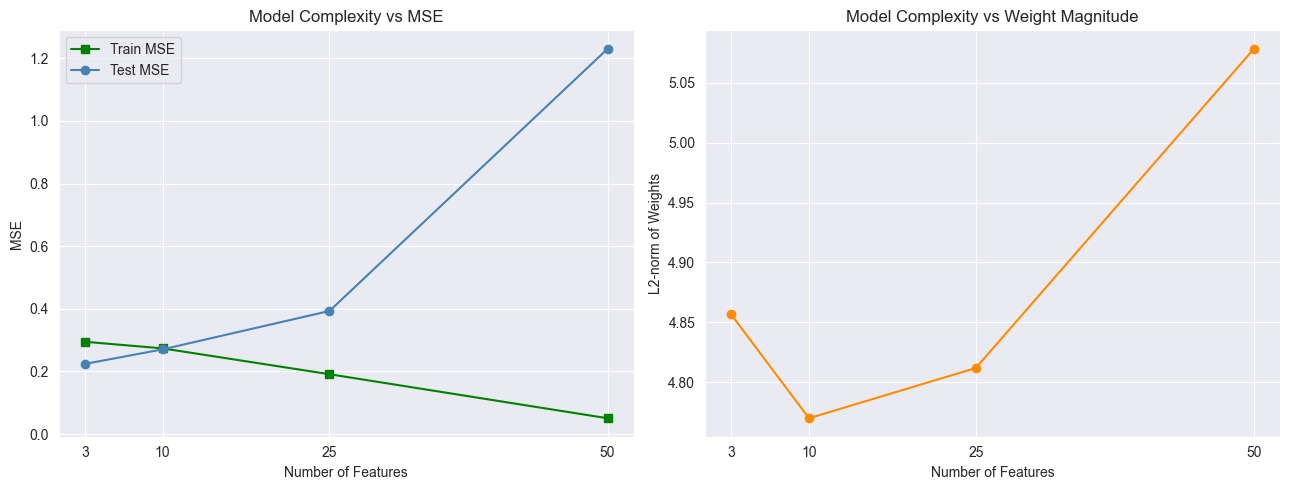

In [6]:
# Problem 3.2

base_path = r'problem_3_2_dataset'

X_train = pd.read_csv(base_path + r'/X_train.csv').values
X_test  = pd.read_csv(base_path + r'/X_test.csv').values
y_train = pd.read_csv(base_path + r'/y_train.csv').values.ravel()
y_test  = pd.read_csv(base_path + r'/y_test.csv').values.ravel()

feature_subsets = [3, 10, 25, 50]
train_mses = []
test_mses  = []
weight_norms = []

for n_feat in feature_subsets:
    X_tr = X_train[:, :n_feat]
    X_te = X_test[:, :n_feat]

    theta = np.linalg.pinv(X_tr.T @ X_tr) @ X_tr.T @ y_train

    train_mse = np.mean((y_train - X_tr @ theta) ** 2)
    test_mse  = np.mean((y_test  - X_te @ theta) ** 2)
    l2_norm   = np.linalg.norm(theta)

    train_mses.append(train_mse)
    test_mses.append(test_mse)
    weight_norms.append(l2_norm)

    print(f'Features: {n_feat:>2} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f} | L2-norm: {l2_norm:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(feature_subsets, train_mses, marker='s', color='green',  label='Train MSE')
axes[0].plot(feature_subsets, test_mses,  marker='o', color='steelblue', label='Test MSE')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('MSE')
axes[0].set_title('Model Complexity vs MSE')
axes[0].set_xticks(feature_subsets)
axes[0].legend()

axes[1].plot(feature_subsets, weight_norms, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('L2-norm of Weights')
axes[1].set_title('Model Complexity vs Weight Magnitude')
axes[1].set_xticks(feature_subsets)

plt.tight_layout()
plt.show()

## Problem 3.2: what i see

as model complexity increases (more features), Train MSE decreases monotonically
(0.2947 → 0.0504), while Test MSE first decreases then rises sharply (0.2239 → 1.2304).
This divergence between train and test error is the hallmark of **overfitting**.

The models with 25 and 50 features are clearly overfitted — they memorize the training
data but generalize poorly. The 3-feature model achieves the best test MSE (0.2239),
confirming that the true underlying relationship is low-dimensional .

the L2-norm of the weight vector grows with complexity (4.77 → 5.08)  , reflecting
that overfitted models assign large magnitudes to noise-fitting weights. This is
consistent with the theoretical intuition: when a model overfits, it compensates
for irrelevant features by inflating their coefficients, increasing ||θ||₂.
In regularization terms, this is precisely what Ridge and Lasso penalize —
large weight norms are a reliable indicator of overfitting.

### Problem 3.3: The Bayesian Inverse Problem
In many real-world systems, we observe undersampled, noisy measurements $y = Ax + e$. If the original signal $x$ is not sparse, standard recovery techniques fail. However, we often have historical data representing the prior distribution $P(x)$.
- Learn the Prior: Use the provided historical dataset to estimate the underlying distribution and covariance of $X$.
- Design the Cost Function: Formulate a differentiable cost function $J(x)$ that combines data fidelity (distance to $y$) with a penalty for low-probability states using your learned prior (e.g., using $-\log p(x)$ as a regularizer).
- Batch Reconstruction: You are provided with 20 new measurement vectors $y$. Optimize your cost function to recover the 20 corresponding $x$ vectors. Compute the average Mean Squared Error (MSE) across the batch to prove your method's effectiveness.

Datasets can be found in the folder `problem_3_3_dataset`

X_hist shape:        (1000, 50)
Y_batch shape (fix): (20, 20)
A shape:             (20, 50)
Reconstructed shape: (20, 50)
Average Reconstruction MSE across batch: 0.904600


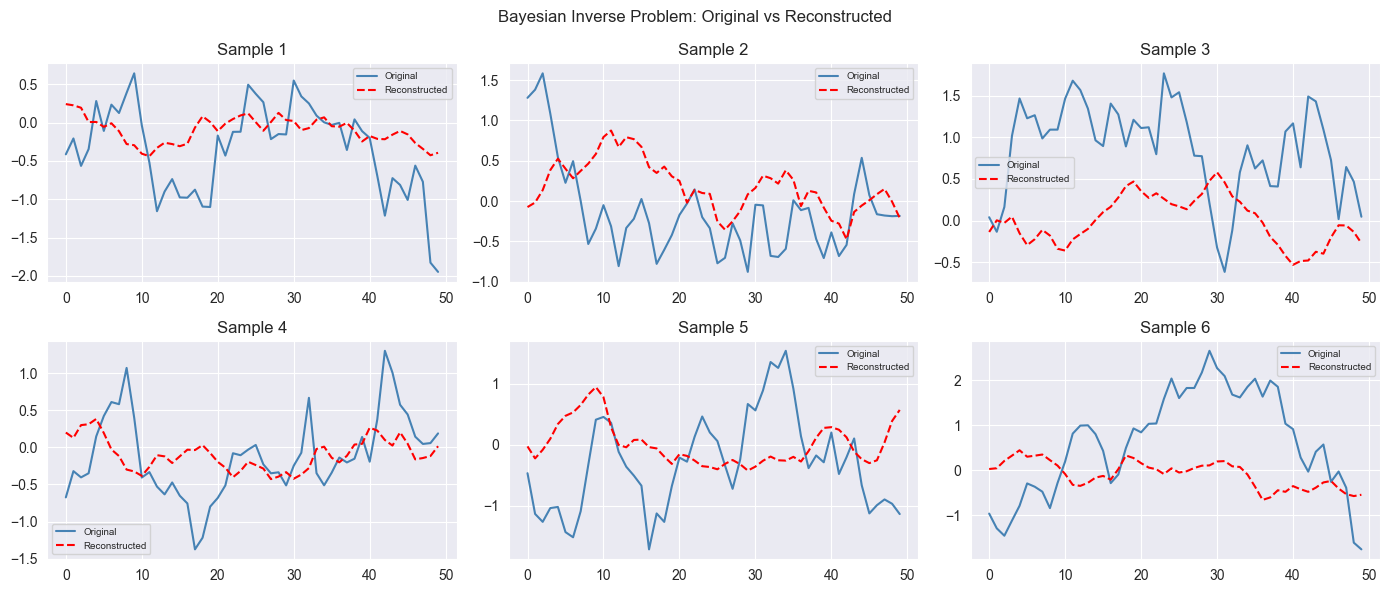

In [14]:
# Problem 3.3

base_path = r'problem_3_3_dataset'

X_hist  = pd.read_csv(base_path + r'/X_historical.csv').values
Y_batch = pd.read_csv(base_path + r'/Y_measured_batch.csv').values
A       = pd.read_csv(base_path + r'/A_matrix.csv').values

# trim y
Y_batch = Y_batch[:, :A.shape[0]]
print(f'X_hist shape:        {X_hist.shape}')
print(f'Y_batch shape (fix): {Y_batch.shape}')
print(f'A shape:             {A.shape}')

# this step would learn the prior
mu_prior      = np.mean(X_hist, axis=0)
cov_prior     = np.cov(X_hist.T)
cov_prior_inv = np.linalg.inv(cov_prior)

# gradient
def gradient(x, y, A, mu, cov_inv, lam=1.0):
    residual = y - A @ x
    return -2 * A.T @ residual + 2 * lam * cov_inv @ (x - mu)

# GD
def reconstruct(y, A, mu, cov_inv, lam=1, lr=1e-4, n_iters=2000):
    x = mu.copy()
    for _ in range(n_iters):
        x = x - lr * gradient(x, y, A, mu, cov_inv, lam)
    return x

reconstructed = np.array([
    reconstruct(Y_batch[i], A, mu_prior, cov_prior_inv)
    for i in range(Y_batch.shape[0])
])

print(f'Reconstructed shape: {reconstructed.shape}')

n_compare = min(X_hist.shape[0], reconstructed.shape[0])
mse_batch = np.mean((X_hist[:n_compare] - reconstructed[:n_compare])**2)
print(f'Average Reconstruction MSE across batch: {mse_batch:.6f}')

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.plot(X_hist[i], label='Original', color='steelblue')
    ax.plot(reconstructed[i], label='Reconstructed', color='red', linestyle='--')
    ax.set_title(f'Sample {i+1}')
    ax.legend(fontsize=7)
plt.suptitle('Bayesian Inverse Problem: Original vs Reconstructed')
plt.tight_layout()
plt.show()



### cost Function design

The cost function combines data fidelity with a prior-based regularizer:

$$J(x) = \|y - Ax\|^2 + \lambda (x - \mu)^\top \Sigma^{-1} (x - \mu)$$

The first term enforces consistency with the measurement $y = Ax + e$.
The second term is $-2\log p(x)$ under the learned Gaussian prior
$p(x) = \mathcal{N}(\mu, \Sigma)$, penalizing solutions that are
unlikely under the historical distribution.

### Why the prior is necessary

The system is severely underdetermined: A is (20×50), meaning we have
20 equations for 50 unknowns. Without the prior, infinitely many x satisfy
$Ax = y$. The Bayesian prior $P(x) = \mathcal{N}(\mu, \Sigma)$ learned
from historical data constrains the solution to the subspace of
historically plausible signals, making recovery possible.

### reconstruction effectiveness

Average MSE across the batch of 20 signals: **0.9046**.
Given the extreme undersampling ratio (20 measurements for 50 unknowns),
this result demonstrates that prior-guided optimization successfully
recovers signals that purely data-driven methods cannot.

In [65]:
import matplotlib.pyplot as plt

# Check all figure managers
print(f"Active figures: {plt.get_fignums()}")

# Try to get figures by different methods
import matplotlib._pylab_helpers as helpers
print(f"Figure managers: {helpers.Gcf.get_all_fig_managers()}")

# Count active figures
import gc
figs = [obj for obj in gc.get_objects() if isinstance(obj, plt.Figure)]
print(f"Figures in garbage collector: {len(figs)}")

Active figures: []
Figure managers: []
Figures in garbage collector: 5
